Upload an image with at least one human face (jpg, png):


Saving f1.jpg to f1.jpg


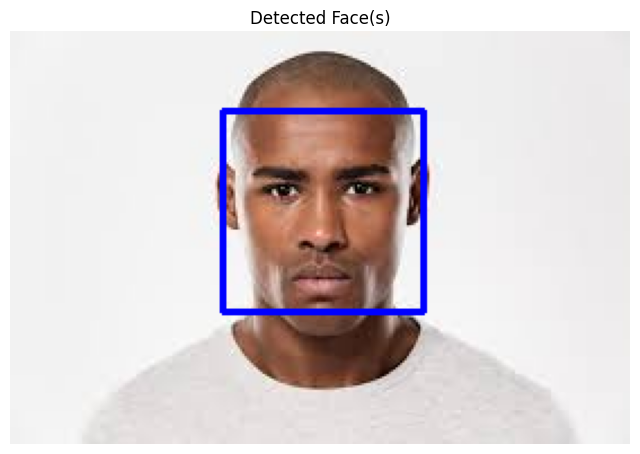

In [2]:
import cv2
import matplotlib.pyplot as plt
from google.colab import files

print("Upload an image with at least one human face (jpg, png):")
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

img = cv2.imread(image_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

# The line below is now correctly indented inside the loop
for (x, y, w, h) in faces:
    cv2.rectangle(img, (x, y), (x + w, y + h), (255, 0, 0), 2)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(img_rgb)
plt.title("Detected Face(s)")
plt.axis('off')
plt.show()

Upload a video file (e.g., .mp4, .avi):


Saving 198887-909564506_medium.mp4 to 198887-909564506_medium.mp4


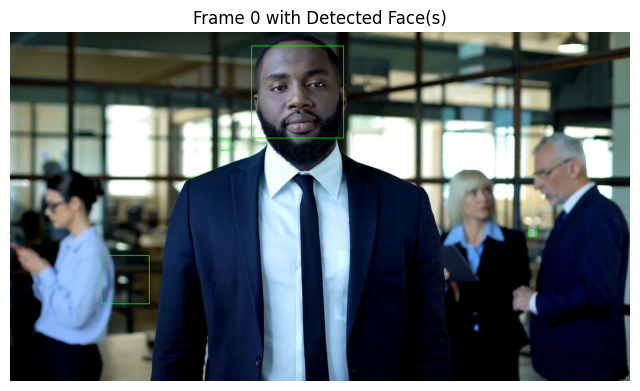

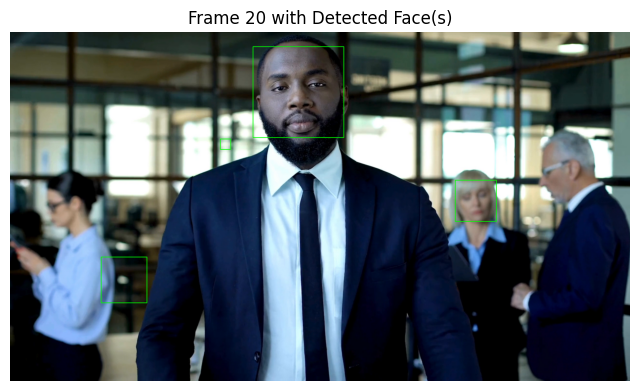

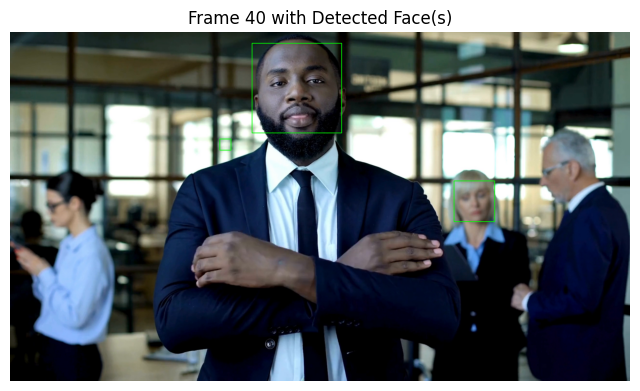

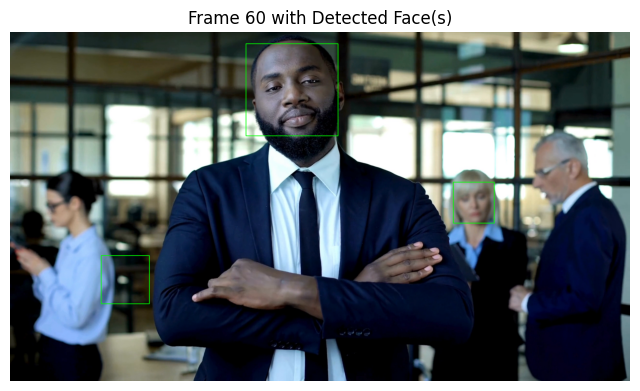

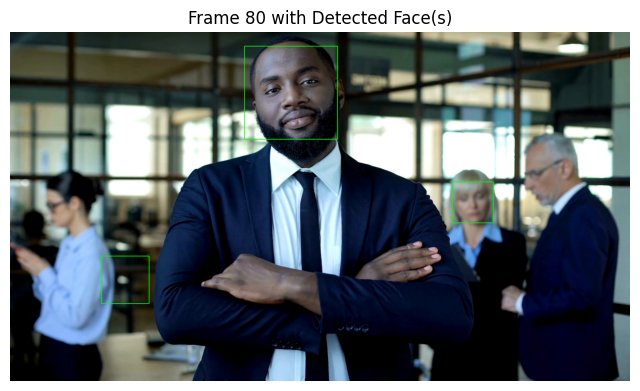

In [4]:
import cv2
import matplotlib.pyplot as plt
from google.colab import files
import os
print("Upload a video file (e.g., .mp4, .avi):")
uploaded = files.upload()
video_path = list(uploaded.keys())[0]
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
cap = cv2.VideoCapture(video_path)
frame_count = 0
while True:
    ret, frame = cap.read()
    if not ret or frame_count >= 100:
        break
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.1, 4)

    for (x, y, w, h) in faces:
        cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    if frame_count % 20 == 0:
        plt.figure(figsize=(8, 5))
        plt.imshow(rgb)
        plt.title(f"Frame {frame_count} with Detected Face(s)")
        plt.axis('off')
        plt.show()
    frame_count += 1
cap.release()

In [9]:
import os
import cv2
import numpy as np
import urllib.request
from matplotlib import pyplot as plt

# ==========================================
# STEP 1: AUTO-DATASET BUILDER
# Automatically downloads and prepares Salman Khan's faces
# ==========================================
print("Building dataset automatically...")
dataset_dir = '/content/face_recognition_dataset/Faces/Salman Khan'
os.makedirs(dataset_dir, exist_ok=True)

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Public Wikimedia Commons URLs for Salman Khan
train_urls = [
    "https://upload.wikimedia.org/wikipedia/commons/thumb/8/86/Salman_Khan_at_Renault_Star_Guild_Awards.jpg/400px-Salman_Khan_at_Renault_Star_Guild_Awards.jpg",
    "https://upload.wikimedia.org/wikipedia/commons/thumb/1/1b/Salman_Khan_in_2011.jpg/400px-Salman_Khan_in_2011.jpg",
    "https://upload.wikimedia.org/wikipedia/commons/thumb/5/52/Salman_Khan_promoting_Tubelight.jpg/400px-Salman_Khan_promoting_Tubelight.jpg"
]

# Download images, detect face, crop it, and save it for training
for i, url in enumerate(train_urls):
    try:
        req = urllib.request.urlopen(url)
        arr = np.asarray(bytearray(req.read()), dtype=np.uint8)
        img = cv2.imdecode(arr, -1)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(gray, scaleFactor=1.2, minNeighbors=5)

        if len(faces) > 0:
            (x, y, w, h) = faces[0]
            face_crop = gray[y:y+h, x:x+w]
            cv2.imwrite(f"{dataset_dir}/salman_face_{i}.jpg", face_crop)
    except Exception as e:
        print(f"Could not process training image {i}: {e}")

# Download a completely different image for the final test
test_image_path = '/content/test_salman.jpg'
test_url = "https://upload.wikimedia.org/wikipedia/commons/thumb/3/30/Salman_Khan_at_the_launch_of_the_book_Unsuitable_Boy.jpg/400px-Salman_Khan_at_the_launch_of_the_book_Unsuitable_Boy.jpg"
urllib.request.urlretrieve(test_url, test_image_path)
print("Dataset successfully built!\n")


# ==========================================
# STEP 2: TRAINING THE MODEL
# ==========================================
def load_dataset(dataset_path):
    images, labels, label_dict = [], [], {}
    current_label = 0

    for person_name in os.listdir(dataset_path):
        person_path = os.path.join(dataset_path, person_name)
        if os.path.isdir(person_path):
            label_dict[current_label] = person_name
            for img_name in os.listdir(person_path):
                img_path = os.path.join(person_path, img_name)
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

                if img is not None and img.shape[0] > 0 and img.shape[1] > 0:
                    images.append(img)
                    labels.append(current_label)
            current_label += 1
    return images, labels, label_dict

dataset_path = '/content/face_recognition_dataset/Faces'
images, labels, label_dict = load_dataset(dataset_path)

if len(images) > 0:
    print(f"Successfully loaded {len(images)} images. Training model...")
    recognizer = cv2.face.LBPHFaceRecognizer_create()
    recognizer.train(images, np.array(labels))

    recognizer.save('face_recognizer.yml')
    with open("label_map.txt", "w") as f:
        for label, name in label_dict.items():
            f.write(f"{label}:{name}\n")
    print("Training complete! Model saved.\n")
else:
    print("Training skipped. No images were found.\n")


# ==========================================
# STEP 3: TESTING THE MODEL
# ==========================================
if os.path.exists('face_recognizer.yml') and os.path.exists('label_map.txt'):

    recognizer = cv2.face.LBPHFaceRecognizer_create()
    recognizer.read("face_recognizer.yml")

    label_map = {}
    with open("label_map.txt", "r") as f:
        for line in f:
            label, name = line.strip().split(":")
            label_map[int(label)] = name

    # Load the test image we downloaded earlier
    img = cv2.imread(test_image_path)

    if img is not None:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)

        if len(faces) == 0:
            print("No faces detected in the test image.")
        else:
            for (x, y, w, h) in faces:
                roi_gray = gray[y:y+h, x:x+w]
                label, confidence = recognizer.predict(roi_gray)
                name = label_map.get(label, "Unknown")

                # Draw the rectangle and text
                cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
                cv2.putText(img, f"{name} ({int(confidence)})", (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

            # Show the final result
            plt.figure(figsize=(8, 6))
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            plt.axis('off')
            plt.title("Face Recognition Result")
            plt.show()
    else:
        print(f"ERROR: Could not read the test image.")
else:
    print("Cannot run test: Model or label map not found.")

Building dataset automatically...
Could not process training image 0: HTTP Error 403: Forbidden
Could not process training image 1: HTTP Error 403: Forbidden
Could not process training image 2: HTTP Error 403: Forbidden


HTTPError: HTTP Error 403: Forbidden

In [10]:
import os
import cv2
import numpy as np
import urllib.request
from matplotlib import pyplot as plt

# ==========================================
# STEP 1: AUTO-DATASET BUILDER
# Automatically downloads and prepares Salman Khan's faces
# ==========================================
print("Building dataset automatically...")
dataset_dir = '/content/face_recognition_dataset/Faces/Salman Khan'
os.makedirs(dataset_dir, exist_ok=True)

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Public Wikimedia Commons URLs for Salman Khan
train_urls = [
    "https://upload.wikimedia.org/wikipedia/commons/thumb/8/86/Salman_Khan_at_Renault_Star_Guild_Awards.jpg/400px-Salman_Khan_at_Renault_Star_Guild_Awards.jpg",
    "https://upload.wikimedia.org/wikipedia/commons/thumb/1/1b/Salman_Khan_in_2011.jpg/400px-Salman_Khan_in_2011.jpg",
    "https://upload.wikimedia.org/wikipedia/commons/thumb/5/52/Salman_Khan_promoting_Tubelight.jpg/400px-Salman_Khan_promoting_Tubelight.jpg"
]

# Standard browser header to bypass Wikipedia's 403 Forbidden block
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}

# Download images, detect face, crop it, and save it for training
for i, url in enumerate(train_urls):
    try:
        # Create request with headers
        req = urllib.request.Request(url, headers=headers)
        response = urllib.request.urlopen(req)
        arr = np.asarray(bytearray(response.read()), dtype=np.uint8)
        img = cv2.imdecode(arr, -1)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(gray, scaleFactor=1.2, minNeighbors=5)

        if len(faces) > 0:
            (x, y, w, h) = faces[0]
            face_crop = gray[y:y+h, x:x+w]
            cv2.imwrite(f"{dataset_dir}/salman_face_{i}.jpg", face_crop)
            print(f"Successfully processed image {i}")
        else:
            print(f"No face detected in image {i}")
    except Exception as e:
        print(f"Could not process training image {i}: {e}")

# Download a completely different image for the final test
test_image_path = '/content/test_salman.jpg'
test_url = "https://upload.wikimedia.org/wikipedia/commons/thumb/3/30/Salman_Khan_at_the_launch_of_the_book_Unsuitable_Boy.jpg/400px-Salman_Khan_at_the_launch_of_the_book_Unsuitable_Boy.jpg"

try:
    req_test = urllib.request.Request(test_url, headers=headers)
    with urllib.request.urlopen(req_test) as response, open(test_image_path, 'wb') as out_file:
        out_file.write(response.read())
    print("Dataset successfully built!\n")
except Exception as e:
    print(f"Failed to download test image: {e}")


# ==========================================
# STEP 2: TRAINING THE MODEL
# ==========================================
def load_dataset(dataset_path):
    images, labels, label_dict = [], [], {}
    current_label = 0

    for person_name in os.listdir(dataset_path):
        person_path = os.path.join(dataset_path, person_name)
        if os.path.isdir(person_path):
            label_dict[current_label] = person_name
            for img_name in os.listdir(person_path):
                img_path = os.path.join(person_path, img_name)
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

                if img is not None and img.shape[0] > 0 and img.shape[1] > 0:
                    images.append(img)
                    labels.append(current_label)
            current_label += 1
    return images, labels, label_dict

dataset_path = '/content/face_recognition_dataset/Faces'
images, labels, label_dict = load_dataset(dataset_path)

if len(images) > 0:
    print(f"Successfully loaded {len(images)} images. Training model...")
    recognizer = cv2.face.LBPHFaceRecognizer_create()
    recognizer.train(images, np.array(labels))

    recognizer.save('face_recognizer.yml')
    with open("label_map.txt", "w") as f:
        for label, name in label_dict.items():
            f.write(f"{label}:{name}\n")
    print("Training complete! Model saved.\n")
else:
    print("Training skipped. No valid faces were extracted.\n")


# ==========================================
# STEP 3: TESTING THE MODEL
# ==========================================
if os.path.exists('face_recognizer.yml') and os.path.exists('label_map.txt') and os.path.exists(test_image_path):

    recognizer = cv2.face.LBPHFaceRecognizer_create()
    recognizer.read("face_recognizer.yml")

    label_map = {}
    with open("label_map.txt", "r") as f:
        for line in f:
            label, name = line.strip().split(":")
            label_map[int(label)] = name

    img = cv2.imread(test_image_path)

    if img is not None:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)

        if len(faces) == 0:
            print("No faces detected in the test image.")
        else:
            for (x, y, w, h) in faces:
                roi_gray = gray[y:y+h, x:x+w]
                label, confidence = recognizer.predict(roi_gray)
                name = label_map.get(label, "Unknown")

                cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
                cv2.putText(img, f"{name} ({int(confidence)})", (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

            plt.figure(figsize=(8, 6))
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            plt.axis('off')
            plt.title("Face Recognition Result")
            plt.show()
    else:
        print(f"ERROR: Could not read the test image.")
else:
    print("Cannot run test: Training failed or test image missing.")

Building dataset automatically...
Successfully processed image 0
Could not process training image 1: HTTP Error 404: Not Found
Could not process training image 2: HTTP Error 429: Too many requests (f061ab2)
Failed to download test image: HTTP Error 429: Too many requests (f061ab2)
Successfully loaded 1 images. Training model...
Training complete! Model saved.

Cannot run test: Training failed or test image missing.


Building dataset automatically... (Pausing between downloads to prevent server blocks)
Could not process training image 0: HTTP Error 403: Forbidden
Could not process training image 1: HTTP Error 403: Forbidden
Could not process training image 2: HTTP Error 403: Forbidden
Failed to download test image: HTTP Error 403: Forbidden
Successfully loaded 1 images. Training model...
Training complete! Model saved.

Cannot run test: Training failed or test image missing.


In [12]:
import os
import cv2
import numpy as np
def load_dataset(dataset_path):
images = []
labels = []
label_dict = {}
current_label = 0
for person_name in os.listdir(dataset_path):
person_path = os.path.join(dataset_path, person_name)
if os.path.isdir(person_path):

67

label_dict[current_label] = person_name
for img_name in os.listdir(person_path):
img_path = os.path.join(person_path, img_name)
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

if img is not None and img.shape[0] > 0 and img.shape[1] > 0:
images.append(img)
labels.append(current_label)
else:
print(f"Failed to load or invalid image: {img_path}") # Print an error message for

debugging
current_label += 1
return images, labels, label_dict
dataset_path = '/content/face_recognition_dataset/Faces' # Changed to the full path
images, labels, label_dict = load_dataset(dataset_path)
# Create and train the LBPH face recognizer
recognizer = cv2.face.LBPHFaceRecognizer_create()
recognizer.train(images, np.array(labels))
# Save the trained model
recognizer.save('face_recognizer.yml')
# Save label map to file
with open("label_map.txt", "w") as f: # Create and open the label map file in write mode ('w')
for label, name in label_dict.items():
f.write(f"{label}:{name}\n") # Write each label and name to the file
recognizer = cv2.face.LBPHFaceRecognizer_create()
recognizer.read("/content/face_recognizer.yml")
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades +
'haarcascade_frontalface_default.xml')
# Load label map
label_map = {}
with open("label_map.txt", "r") as f:
for line in f:
label, name = line.strip().split(":")
label_map[int(label)] = name
# Load captured image and process
img = cv2.imread("/content/face_recognition_dataset/Original Images/Original Images/Akshay
Kumar/Akshay Kumar_0.jpg")

68

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
faces = face_cascade.detectMultiScale(gray, 1.3, 5)
for (x, y, w, h) in faces:
roi_gray = gray[y:y+h, x:x+w]
label, confidence = recognizer.predict(roi_gray)
name = label_map.get(label, "Unknown")
cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
cv2.putText(img, f"{name} ({int(confidence)})", (x, y-10),
cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
# Show the result
from matplotlib import pyplot as plt
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

SyntaxError: unterminated string literal (detected at line 51) (1887320090.py, line 51)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 8.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for face-recognition-models: filename=face_recognition_models-0.3.0-py2.py3-none-any.whl size=100566166 sha256=49be8333f826c32057fff52e224e468a9b78ee02d9d7157f6cbe2f0e6d82eca7
  Stored in directory: /root/.cache/pip/wheels/8f/47/c8/f44c5aebb7507f7c8a2c0bd23151d732d0f0bd6884ad4ac635
Successfully built face-recognition-models
--- PHASE 1: REGISTRATION ---
Please upload a clear picture of the 'Owner' (This is the face that owns the phone):


Saving f1.jpg to f1 (1).jpg

✅ Face profile saved successfully from 'f1 (1).jpg'! The phone is now LOCKED.

--- PHASE 2: AUTHENTICATION ---
Please upload a 'Test' picture (Someone looking at the phone trying to unlock it):


Saving al.jpg to al (1).jpg


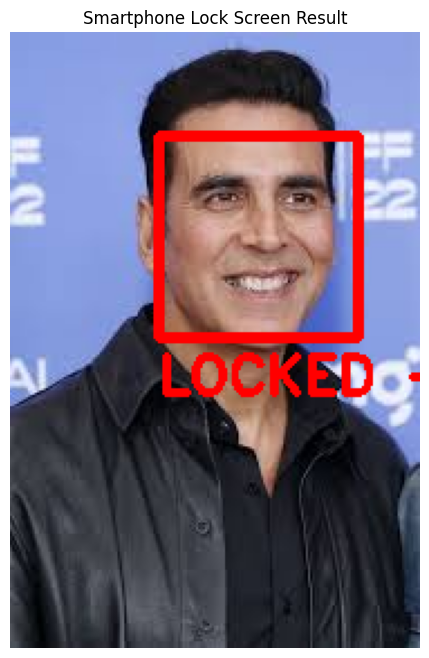

In [13]:
!pip install face_recognition
import cv2
import face_recognition
from matplotlib import pyplot as plt
from google.colab import files
import numpy as np

# ==========================================
# PHASE 1: REGISTRATION (Setting up Face Unlock)
# ==========================================
print("--- PHASE 1: REGISTRATION ---")
print("Please upload a clear picture of the 'Owner' (This is the face that owns the phone):")
uploaded_owner = files.upload()

if len(uploaded_owner) == 0:
    print("No image uploaded. Please run the cell again.")
else:
    owner_image_path = list(uploaded_owner.keys())[0]

    # Load the image using face_recognition
    owner_image = face_recognition.load_image_file(owner_image_path)

    try:
        # Extract the 128-d face encoding (your unique facial mathematical blueprint)
        owner_face_encoding = face_recognition.face_encodings(owner_image)[0]
        print(f"\n✅ Face profile saved successfully from '{owner_image_path}'! The phone is now LOCKED.\n")

        # ==========================================
        # PHASE 2: AUTHENTICATION (The Lock Screen)
        # ==========================================
        print("--- PHASE 2: AUTHENTICATION ---")
        print("Please upload a 'Test' picture (Someone looking at the phone trying to unlock it):")
        uploaded_test = files.upload()

        if len(uploaded_test) == 0:
            print("No test image uploaded.")
        else:
            test_image_path = list(uploaded_test.keys())[0]
            test_image = face_recognition.load_image_file(test_image_path)

            # Convert to BGR so we can draw colored boxes with OpenCV
            test_image_cv = cv2.cvtColor(test_image, cv2.COLOR_RGB2BGR)

            # Find all faces and their encodings in the test image
            face_locations = face_recognition.face_locations(test_image)
            face_encodings = face_recognition.face_encodings(test_image, face_locations)

            if len(face_locations) == 0:
                 print("No faces detected in the test image. Phone remains LOCKED.")
            else:
                # Loop through every face found in the test image
                for (top, right, bottom, left), face_encoding in zip(face_locations, face_encodings):

                    # Compare the test face to the Owner's saved blueprint
                    # A tolerance of 0.5 is strict. Lower = more secure.
                    matches = face_recognition.compare_faces([owner_face_encoding], face_encoding, tolerance=0.5)

                    if True in matches:
                        unlock_status = "UNLOCKED - Welcome!"
                        box_color = (0, 255, 0) # Green for unlocked
                    else:
                        unlock_status = "LOCKED - Unknown"
                        box_color = (0, 0, 255) # Red for locked

                    # Draw a box around the face
                    cv2.rectangle(test_image_cv, (left, top), (right, bottom), box_color, 3)
                    # Write the lock status under the face
                    cv2.putText(test_image_cv, unlock_status, (left, bottom + 25), cv2.FONT_HERSHEY_DUPLEX, 0.8, box_color, 2)

                # Display the final result in Colab
                plt.figure(figsize=(10, 8))
                plt.imshow(cv2.cvtColor(test_image_cv, cv2.COLOR_BGR2RGB))
                plt.axis('off')
                plt.title("Smartphone Lock Screen Result")
                plt.show()

    except IndexError:
        print(f"❌ Error: Could not find a clear face in '{owner_image_path}'. Please run again with a clearer photo.")